# 06 · Global health: access when roads close

**Mission:** use a graph to compare access to open facilities before and after road closures. Allow 40 minutes. Prerequisites: Labs 03–04.

**Run:** choose the Python (Pyodide) kernel in JupyterLite, then Run → Run All Cells. First use downloads Matplotlib. All training data are **SYNTHETIC** unless explicitly labeled LIVE. Downloads appear below and in `exports/`; the browser filesystem is separate from your computer. Each lab runs independently.

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("matplotlib")
import json, math
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from worldview_lab import (load, export, map_layer, chart_style, haversine_km,
    wilson_interval, shortest_times, freshness, normalize_quakes,
    validate_geojson, brief_request, validate_brief)
chart_style()

## Transferable method, fictional geography

This small graph represents travel times between district centroids. It demonstrates a method applicable to global health planning; it is not a global coverage estimate. Roads, speeds, facility assignments, and closures are synthetic. Each district’s population is assigned to its centroid, an approximation that hides within-district inequality.

In [2]:
network=load('network.json');districts=load('districts.geojson');facilities=load('facilities.geojson')
open_nodes=[network['facility_nodes'][f['id']] for f in facilities['features'] if f['properties']['open']]
def access(closures):
    times=[shortest_times(network,node,closures) for node in open_nodes]
    return {node:min(t[node] for t in times) for node in network['nodes']}
before,after=access(False),access(True)
display({'before_minutes':before,'after_minutes':after})

{'before_minutes': {'D01': 0,
  'D02': 9,
  'D03': 19,
  'D04': 20,
  'D05': 9,
  'D06': 0,
  'D07': 11,
  'D08': 10,
  'D09': 21,
  'D10': 14,
  'D11': 13,
  'D12': 0},
 'after_minutes': {'D01': 0,
  'D02': 9,
  'D03': 20,
  'D04': 20,
  'D05': 9,
  'D06': 0,
  'D07': 23,
  'D08': 10,
  'D09': 21,
  'D10': 14,
  'D11': 13,
  'D12': 0}}

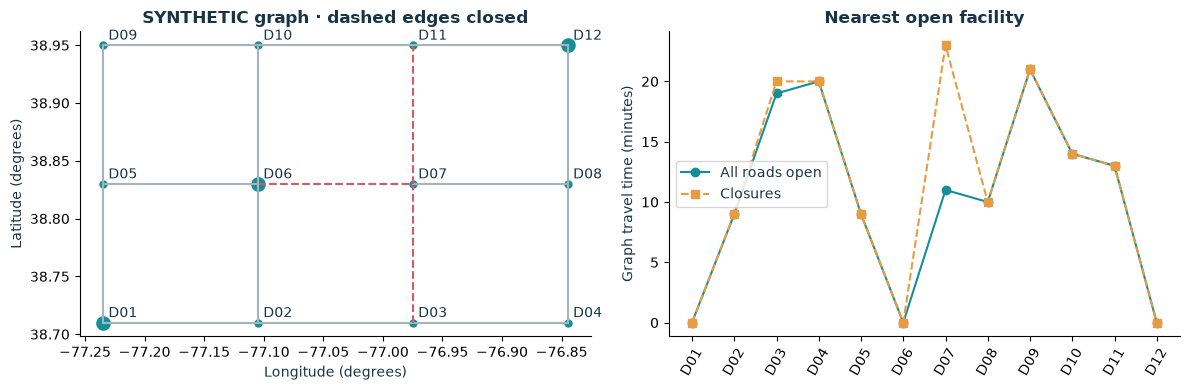

In [3]:
fig,axs=plt.subplots(1,2,figsize=(12,4))
for e in network['edges']:
    a,b=network['nodes'][e['a']],network['nodes'][e['b']]
    axs[0].plot([a[0],b[0]],[a[1],b[1]],'--' if e['closed'] else '-',color='#d45b63' if e['closed'] else '#a4b3bc')
for node,(lon,lat) in network['nodes'].items():
    axs[0].scatter(lon,lat,s=90 if node in open_nodes else 25,color='#148f97');axs[0].annotate(node,(lon,lat),xytext=(4,4),textcoords='offset points')
axs[0].set(title='SYNTHETIC graph · dashed edges closed',xlabel='Longitude (degrees)',ylabel='Latitude (degrees)')
axs[1].plot(list(before),list(before.values()),'o-',label='All roads open')
axs[1].plot(list(after),list(after.values()),'s--',label='Closures')
axs[1].set(title='Nearest open facility',ylabel='Graph travel time (minutes)');axs[1].legend();axs[1].tick_params(axis='x',rotation=60)
fig.tight_layout();plt.show()

In [4]:
THRESHOLD=15
population=sum(f['properties']['population'] for f in districts['features'])
covered=sum(f['properties']['population'] for f in districts['features'] if after[f['id']]<=THRESHOLD)
print(f'Population within {THRESHOLD} synthetic minutes: {covered:,}/{population:,} ({covered/population:.1%})')
for f in districts['features']:
    t=after[f['id']];f['properties']['travel_minutes']=None if math.isinf(t) else t
export('access.geojson',districts)

Population within 15 synthetic minutes: 145,000/203,500 (71.3%)


WindowsPath('exports/access.geojson')

## Equity and model limits

Change `THRESHOLD` and close a facility. Which populations lose access? An unreachable node has infinite travel time; export it as `null`, not zero. **Checkpoint:** closures can never reduce shortest travel time in this fixed non-negative graph.

This model does not allocate capacity or predict patient choice. Adding all nearby capacity to each district would double-count shared facilities. For a regional application, obtain licensed road data, validated facility status, population surfaces, transport modes, and locally justified thresholds.

**Astra prompt:** “Inspect this graph and computation. Find assumptions about directionality, travel mode, centroids, and capacity. Design tests for disconnected nodes and closures. Keep computed travel times distinct from observed accessibility.”

In [5]:
assert all(after[k]>=before[k] for k in before)

## Sources and attribution

[WHO AccessMod](https://www.who.int/tools/accessmod-geographic-access-to-health-care) provides context for geographic accessibility modeling. The implementation here is a small Dijkstra teaching example, not AccessMod output.

World View inspiration: [Kevin (Khoa) To, MIT](https://github.com/kevtoe/worldview). Original lab code, figures, and synthetic fixtures: JupyterLite WorldView contributors, MIT. See the [book references](https://jltobias.github.io/JupyterLite-WorldView/book/references.html) and repository notices for dependency and service terms.